### Buid A basic chat bot with langraph (Graph API)

In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages #recducer


In [3]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    
    messages: Annotated[list, add_messages]

graph_builder =StateGraph(State)

In [4]:
graph_builder

In [5]:
import os 
from dotenv import load_dotenv
load_dotenv()
#os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


True

In [6]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="openai/gpt-oss-20b")

In [7]:
# we also do like _>
# llm = init_chat_model("groq:llama-3.1-8b-instant")

In [8]:
# Node functionality 
def chatbot(state):
    return {"messages":[llm.invoke(state["messages"])]}


In [9]:
graph_builder = StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)

## Adding edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph = graph_builder.compile()

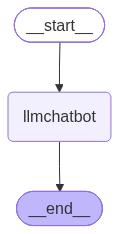

In [10]:
## visulization
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [11]:
responce=graph.invoke({"messages":"Hi how are you"})

In [12]:
responce["messages"][-1]

AIMessage(content="Hello! I'm doing great—thanks for asking. How about you? Anything interesting going on today?", additional_kwargs={'reasoning_content': 'The user says: "Hi how are you". We respond politely. It\'s a greeting. The user hasn\'t asked a question. We can respond with a friendly greeting, maybe ask them how they are. There\'s no special instructions. Just respond.'}, response_metadata={'token_usage': {'completion_tokens': 78, 'prompt_tokens': 75, 'total_tokens': 153, 'completion_time': 0.086891276, 'completion_tokens_details': {'reasoning_tokens': 49}, 'prompt_time': 0.016583377, 'prompt_tokens_details': None, 'queue_time': 0.210836852, 'total_time': 0.103474653}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_851252edc2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a067cd-07ed-75c1-843e-522db2cd3f73-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 75, 'output_toke

In [13]:
for event in graph.stream({"messages":"hi how are you"}):
    for value in event.values():
        print(value["messages"][-1].content)


Hi! I’m doing great—thanks for asking. How about you?


### chat with Tools


In [14]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("what is langgraph")

{'query': 'what is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norwegian Cr

In [15]:
## custom function 
def multply(a:int,b:int)->int:
    """MUTILPY a and  b 
    Args:
    a (int) : first int
    b (int) : second int
        int: output int 
    """


In [16]:
tools = [tool,multply]

In [17]:
llm_with_tool= llm.bind_tools(tools)

In [18]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000286B0D75400>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000286B0D75E80>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and

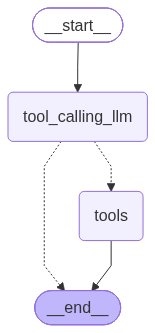

In [19]:
### let's create  state graph 
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node defination
def tool_calling_llm(state):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}
# graph 
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## add edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)
## complie the graph
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
responce=graph.invoke({"messages":"Hi how are you"})

In [21]:
responce["messages"][-1].content

"Hello! I'm just a bundle of code, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?"

In [23]:
for event in graph.stream({"messages":"hi how are you"}):
    for value in event.values():
        print(value["messages"][-1].content )

Hi! I’m doing great—thanks for asking. How can I help you today?
